# Regional EDA — Restricting Presence Data to the Absence Study Area

The main EDA (`pika_presence_absence_EDA.ipynb`) flagged a key confound: presence records span nearly the whole American pika range, while absence records are confined to a single region (the Sierra Nevada / Great Basin / northern Rockies corridor). That mismatch means any presence-vs-absence difference could be regional rather than ecological.

**This notebook tests a specific fix:** restrict the presence data to the geographic area covered by the absence data, rebuild the class balance and key comparisons on that regional subset, and check whether conclusions from the main EDA hold up, change, or reverse. It also quantifies the trade-off directly — restricting scope reduces class imbalance but throws away most of the presence data.

## Contents
1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
2. [Defining "the Region"](#2.-Defining-%22the-Region%22)
3. [Building the Regional Presence Subset](#3.-Building-the-Regional-Presence-Subset)
4. [Class Balance: Before vs. After](#4.-Class-Balance:-Before-vs.-After)
5. [Data Quality Within the Region](#5.-Data-Quality-Within-the-Region)
6. [Spatial Distribution Within the Region](#6.-Spatial-Distribution-Within-the-Region)
7. [Does the Environmental Signal Hold Regionally?](#7.-Does-the-Environmental-Signal-Hold-Regionally?)
8. [Elevation Deep Dive — a Reversal](#8.-Elevation-Deep-Dive-—-a-Reversal)
9. [Correlation Stability Check](#9.-Correlation-Stability-Check)
10. [Summary & Recommendation](#10.-Summary-&-Recommendation)


## 1. Setup & Data Loading

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

# Same colorblind-safe palette (Okabe-Ito) as the main EDA notebook, for visual consistency
STATUS_COLORS = {
    'detected':              '#0072B2',
    'recent absence':        '#E69F00',
    'long absence':          '#D55E00',
    'extirpated_GreatBasin': '#CC79A7',
}
STATUS_ORDER = ['detected', 'recent absence', 'long absence', 'extirpated_GreatBasin']

PRESENCE_PATH = 'presence_pika_final_with_extraTPDSIandSnow.csv'
ABSENCE_PATH  = 'absence_pika_final_with_extraTPDSIandSnow.csv'

presence_df = pd.read_csv(PRESENCE_PATH, low_memory=False)
absence_df  = pd.read_csv(ABSENCE_PATH)

print(f'Full presence data: {presence_df.shape[0]:,} rows')
print(f'Absence data:       {absence_df.shape[0]:,} rows')

Full presence data: 17,949 rows
Absence data:       225 rows


## 2. Defining "the Region"

The simplest, least arbitrary region definition is the **bounding box of the absence data itself** — it directly reflects where the resurvey fieldwork actually happened, with no invented parameter. Before committing to it, though, it's worth checking how sensitive the resulting sample size is to adding a margin around that box (a real ecological region doesn't stop at a hard edge, and a small buffer could recover nearby presence points that are plausibly part of the same landscape).

In [9]:
lat_min, lat_max = absence_df['lat'].min(), absence_df['lat'].max()
lon_min, lon_max = absence_df['long'].min(), absence_df['long'].max()

print(f'Absence bounding box: lat [{lat_min:.3f}, {lat_max:.3f}]  |  long [{lon_min:.3f}, {lon_max:.3f}]')
print(f'Box dimensions: {lat_max-lat_min:.2f} deg latitude x {lon_max-lon_min:.2f} deg longitude')

Absence bounding box: lat [37.746, 48.507]  |  long [-121.995, -114.981]
Box dimensions: 10.76 deg latitude x 7.01 deg longitude


In [10]:
rows = []
for buffer in [0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0]:
    m = (presence_df['lat'].between(lat_min - buffer, lat_max + buffer) &
         presence_df['long'].between(lon_min - buffer, lon_max + buffer))
    n = m.sum()
    rows.append({
        'buffer_deg': buffer,
        'presence_n': n,
        'pct_of_all_presence': n / len(presence_df),
        'presence_to_absence_ratio': n / len(absence_df),
    })

buffer_sensitivity = pd.DataFrame(rows).set_index('buffer_deg')
buffer_sensitivity['pct_of_all_presence'] = (buffer_sensitivity['pct_of_all_presence'] * 100).round(1)
buffer_sensitivity['presence_to_absence_ratio'] = buffer_sensitivity['presence_to_absence_ratio'].round(1)
buffer_sensitivity

,presence_n,pct_of_all_presence,presence_to_absence_ratio
buffer_deg,,,
0.00,4480,25.0,19.9
0.25,5558,31.0,24.7
0.50,6121,34.1,27.2
1.00,6867,38.3,30.5
1.50,8826,49.2,39.2
2.00,9233,51.4,41.0
3.00,10252,57.1,45.6


This puts real numbers on the trade-off: even with **no buffer at all**, restricting to the exact absence bounding box keeps **4,480 presence records (25% of the full presence data)** and improves the imbalance ratio from ~80:1 down to **~20:1** — a 4x improvement, for a 75% data loss. Adding a buffer recovers more points but reintroduces some of the same regional-extent problem we're trying to fix, and the gains taper off quickly (a 3° buffer, over 300 km, still only reaches 57% of the data and ~46:1).

**Decision for this notebook: use the exact absence bounding box (0° buffer).** It's the most defensible choice — directly tied to where absence was actually measured — and still leaves a workable sample. If a modeling pass later needs more data, this table gives a clear menu of buffer options and their cost.

## 3. Building the Regional Presence Subset

In [11]:
in_region = (presence_df['lat'].between(lat_min, lat_max) &
             presence_df['long'].between(lon_min, lon_max))
presence_regional = presence_df[in_region].copy()

shared_cols = sorted(set(presence_df.columns) & set(absence_df.columns))

combined_regional = pd.concat([
    presence_regional[shared_cols].assign(dataset='presence'),
    absence_df[shared_cols].assign(dataset='absence'),
], ignore_index=True)
combined_regional['status_description'] = pd.Categorical(
    combined_regional['status_description'], categories=STATUS_ORDER, ordered=True
)

print(f'Regional presence subset: {len(presence_regional):,} rows (vs. {len(presence_df):,} full presence)')
print(f'Combined regional frame: {combined_regional.shape[0]:,} rows x {combined_regional.shape[1]} columns')

Regional presence subset: 4,480 rows (vs. 17,949 full presence)
Combined regional frame: 4,705 rows x 44 columns


## 4. Class Balance: Before vs. After

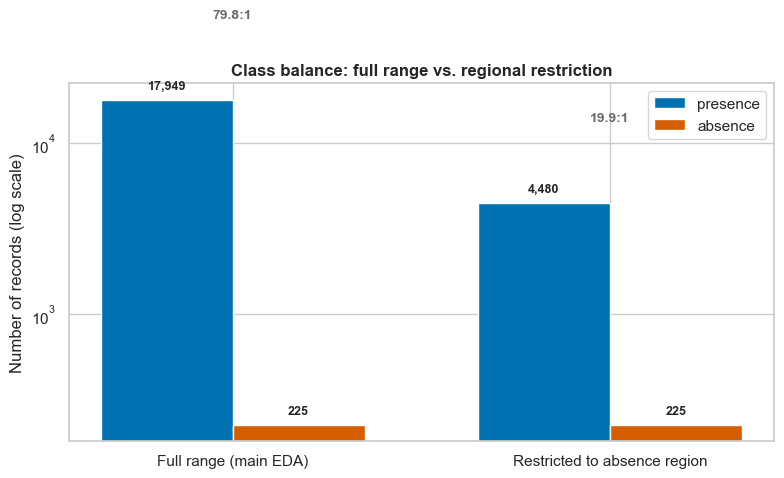

,presence_n,absence_n,ratio
Full range (main EDA),17949,225,79.8
Restricted to absence region,4480,225,19.9


In [12]:
n_absence = len(absence_df)
scenarios = pd.DataFrame({
    'presence_n': [len(presence_df), len(presence_regional)],
    'absence_n': [n_absence, n_absence],
}, index=['Full range (main EDA)', 'Restricted to absence region'])
scenarios['ratio'] = (scenarios['presence_n'] / scenarios['absence_n']).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, scenarios['presence_n'], width, label='presence', color=STATUS_COLORS['detected'])
ax.bar(x + width/2, scenarios['absence_n'], width, label='absence', color=STATUS_COLORS['long absence'])
ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(scenarios.index, rotation=0)
ax.set_ylabel('Number of records (log scale)')
ax.set_title('Class balance: full range vs. regional restriction')
for i, (p, a, r) in enumerate(zip(scenarios['presence_n'], scenarios['absence_n'], scenarios['ratio'])):
    ax.text(i - width/2, p * 1.15, f'{p:,}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + width/2, a * 1.15, f'{a:,}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i, max(p, a) * 3, f'{r}:1', ha='center', fontsize=10, fontweight='bold', color='dimgray')
ax.legend()
plt.tight_layout()
plt.show()

scenarios

Restricting to the absence region roughly **quarters the imbalance ratio** (79.8:1 → 19.9:1) at the cost of **75% of the presence data** (17,949 → 4,480 rows). Whether that trade is worth it depends on what the rest of this notebook finds: if the environmental signal and conclusions hold up regionally, a smaller-but-cleaner regional dataset is arguably more trustworthy than a larger-but-confounded one.

## 5. Data Quality Within the Region

In [13]:
check_cols = ['AnnualMean_PDSI', 'Max_snow', 'elevation', 'slope_deg']
quality_check = pd.DataFrame({
    'regional_presence_missing_%': [presence_regional[c].isna().mean() * 100 for c in check_cols],
    'full_presence_missing_%':     [presence_df[c].isna().mean() * 100 for c in check_cols],
}, index=check_cols).round(1)
quality_check

,regional_presence_missing_%,full_presence_missing_%
AnnualMean_PDSI,20.3,14.9
Max_snow,20.3,14.9
elevation,5.1,5.2
slope_deg,5.7,5.5


Missingness for `elevation`/`slope_deg` is essentially unchanged (~5%). The supplementary PDSI/snow block is actually a bit **more** often missing in the regional subset (~20% vs. ~15% full-range) — worth keeping in mind if the eventual model relies heavily on those variables, since the regional sample for them is a little smaller than the headline 4,480 suggests.

In [14]:
zero_elev_regional = presence_regional[presence_regional['elevation'] == 0.0]
print(f"elevation == 0.0 rows in the regional subset: {len(zero_elev_regional)}")
print(f"(for reference, the full presence data had 36 such rows, {36/len(presence_df):.2%})")
print(f"Regional year range: {int(presence_regional['year'].min())} - {int(presence_regional['year'].max())}")

elevation == 0.0 rows in the regional subset: 0
(for reference, the full presence data had 36 such rows, 0.20%)
Regional year range: 1892 - 2026


The `elevation == 0.0` sentinel issue found in the main EDA **disappears entirely** in the regional subset — those 36 rows sat at the extreme edges of the full presence bounding box (Yukon, coastal BC, etc.), well outside this region. One small, incidental benefit of restricting scope.

## 6. Spatial Distribution Within the Region

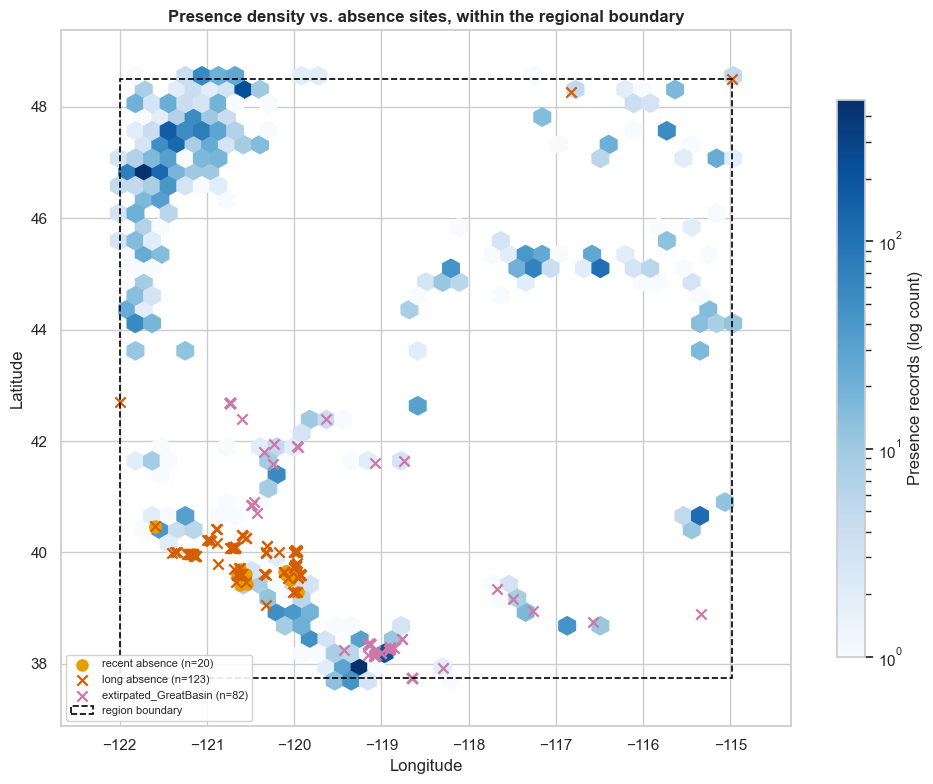

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

hb = ax.hexbin(presence_regional['long'], presence_regional['lat'], gridsize=40,
               cmap='Blues', mincnt=1, bins='log',
               extent=[lon_min - 0.3, lon_max + 0.3, lat_min - 0.3, lat_max + 0.3])
plt.colorbar(hb, ax=ax, label='Presence records (log count)', shrink=0.8)

for status in ['recent absence', 'long absence', 'extirpated_GreatBasin']:
    sub = absence_df[absence_df['status_description'] == status]
    ax.scatter(sub['long'], sub['lat'], s=55, marker='o' if status == 'recent absence' else 'x',
               color=STATUS_COLORS[status], label=f'{status} (n={len(sub)})', linewidths=1.6)

rect = plt.Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
                      fill=False, edgecolor='black', linewidth=1.2, linestyle='--', label='region boundary')
ax.add_patch(rect)

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Presence density vs. absence sites, within the regional boundary')
ax.legend(loc='lower left', framealpha=0.9, fontsize=8)
plt.tight_layout()
plt.show()

Presence and absence now occupy the same footprint by construction — this map is the regional counterpart to the whole-continent map in the main EDA, and it's the visual confirmation that the confound from Section 9 of that notebook has been removed here.

## 7. Does the Environmental Signal Hold Regionally?

This is the central question. The main EDA found presence sites were colder, snowier, and wetter than absence sites — but flagged that this could be a regional artifact. Now that presence is restricted to the same region as absence, does that pattern hold, weaken, or disappear?

In [16]:
compare_vars = {
    'elevation':             'Elevation (m)',
    'bio1_temp_mean_annual': 'BIO1 – Annual Mean Temp (°C)',
    'bio5_temp_max_warm':    'BIO5 – Max Temp Warmest Mo. (°C)',
    'bio6_temp_min_cold':    'BIO6 – Min Temp Coldest Mo. (°C)',
    'bio12_precip_annual':   'BIO12 – Annual Precip (mm)',
    'months_with_snow':      'Months with snow',
    'AnnualMean_PDSI':       'Annual mean PDSI',
    'AnnualMean_swe':        'Annual mean SWE (mm)',
}

rows = []
for col, label in compare_vars.items():
    p_global = presence_df[col].dropna()
    p_regional = presence_regional[col].dropna()
    a = absence_df[col].dropna()
    u_r, pval_r = stats.mannwhitneyu(p_regional, a, alternative='two-sided')
    rows.append({
        'variable': label,
        'presence_median (full range)': p_global.median(),
        'presence_median (regional)': p_regional.median(),
        'absence_median': a.median(),
        'regional_p_value': pval_r,
    })

signal_check = pd.DataFrame(rows).set_index('variable').round(4)
signal_check

,presence_median (full range),presence_median (regional),absence_median,regional_p_value
variable,,,,
Elevation (m),2438.4000,2011.8400,2136.0384,0.0028
BIO1 – Annual Mean Temp (°C),1.5137,3.2212,6.4735,0.0000
BIO5 – Max Temp Warmest Mo. (°C),20.0200,20.2800,26.6480,0.0000
BIO6 – Min Temp Coldest Mo. (°C),-13.0520,-9.2560,-7.5280,0.0000
BIO12 – Annual Precip (mm),677.0000,1112.0000,539.0000,0.0000
Months with snow,6.0000,6.0000,4.0000,0.0000
Annual mean PDSI,-1.8375,-1.8692,1.3200,0.0000
Annual mean SWE (mm),97.2333,181.3000,66.4833,0.0000


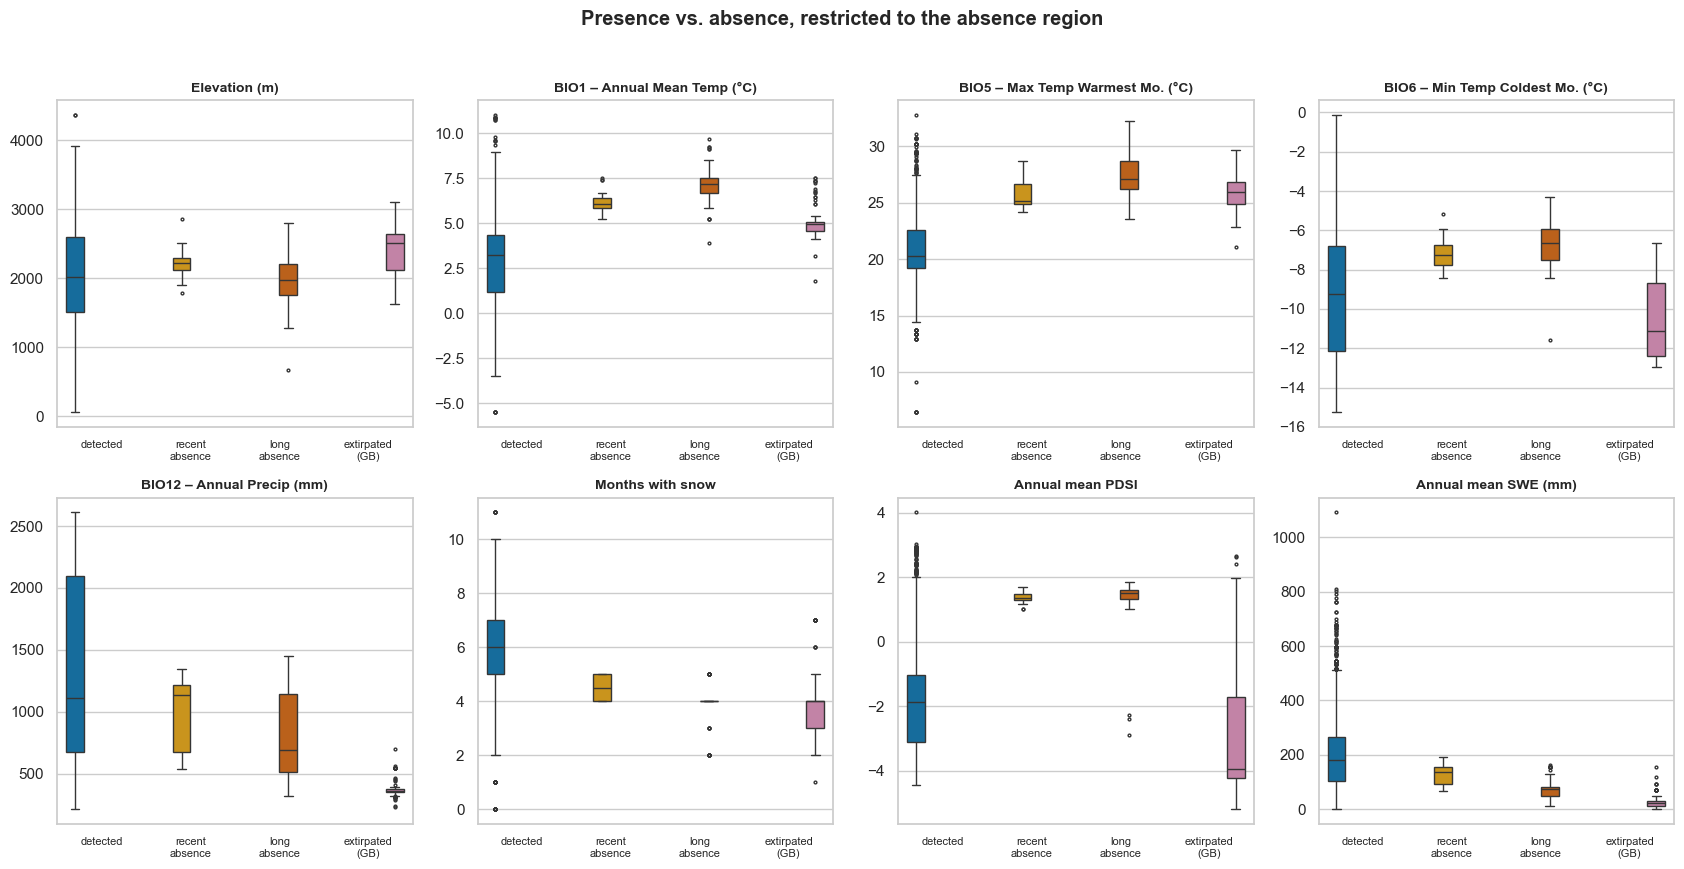

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8.5))
for ax, (col, label) in zip(axes.flat, compare_vars.items()):
    sns.boxplot(data=combined_regional, x='status_description', y=col, order=STATUS_ORDER,
                hue='status_description', palette=STATUS_COLORS, legend=False, ax=ax, fliersize=2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticklabels(['detected', 'recent\nabsence', 'long\nabsence', 'extirpated\n(GB)'], fontsize=8)
fig.suptitle('Presence vs. absence, restricted to the absence region', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Comparing the "full range" and "regional" presence medians against the (unchanged) absence median tells the story:

- **Snow, PDSI, and BIO5** barely move — `months_with_snow` (6.0 in both), `AnnualMean_PDSI` (-1.84 full vs. -1.87 regional), and `AnnualMean_swe` actually widens the gap (97 → 181 mm, further above absence's 66 mm). These look like a **real regional signal**, not a sampling artifact.
- **BIO1 and BIO6** (temperature) keep the same direction (presence colder) but the gap **narrows substantially** once matched by region — e.g. BIO1's presence-absence gap shrinks from ~5.0 °C globally to ~3.3 °C regionally. Part of the original global gap really was just "different regions have different climates," even though a real, smaller signal remains.
- **BIO12** (precipitation) actually widens further in the regional comparison (677 → 1,112 mm), moving *away* from absence rather than toward it.
- **Elevation is the outlier: it flips sign entirely.** See Section 8.

All regional p-values stay far below 0.05 (the smallest effects are still detected given the 4,480-vs-225 sample), but **p-values don't tell us about the confound** — the shrinking/widening gaps above do, and that's the more useful reading here.

## 8. Elevation Deep Dive — a Reversal

This is the headline finding of this notebook. Globally, `detected` (presence) sites had the *highest* median elevation of the four status groups. Restricted to the absence region, that flips.

In [18]:
elev_by_status_regional = combined_regional.groupby('status_description', observed=True)['elevation'].describe()[['count','mean','50%','min','max']].round(1)
elev_by_status_regional.columns = ['count', 'mean', 'median', 'min', 'max']
elev_by_status_regional

,count,mean,median,min,max
status_description,,,,,
detected,4252.0,2061.6,2011.8,62.0,4360.0
recent absence,20.0,2216.1,2218.3,1783.0,2865.1
long absence,123.0,1961.4,1973.0,678.0,2801.1
extirpated_GreatBasin,82.0,2415.6,2515.5,1628.0,3106.0


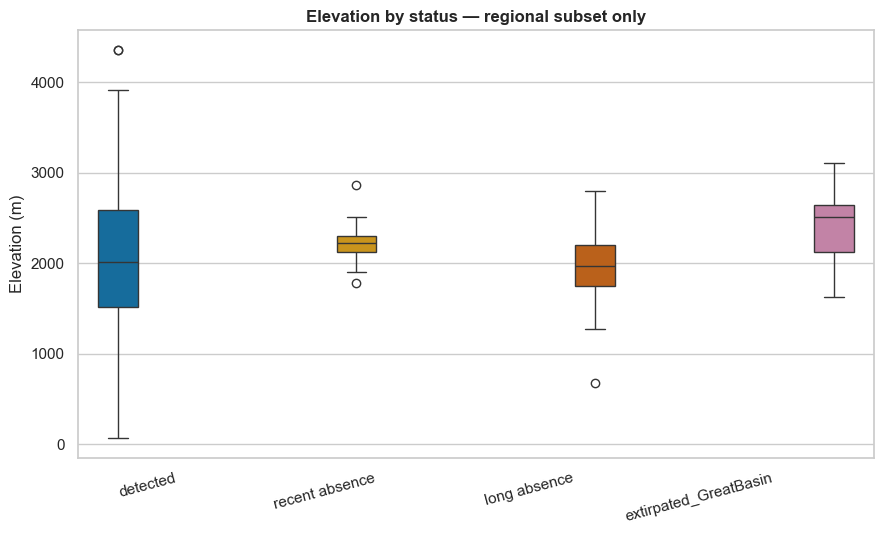

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=combined_regional, x='status_description', y='elevation', order=STATUS_ORDER,
            hue='status_description', palette=STATUS_COLORS, legend=False, ax=ax)
ax.set_title('Elevation by status — regional subset only')
ax.set_xlabel(''); ax.set_ylabel('Elevation (m)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

Within the region, `detected` has a median elevation of **~2,012 m** — *lower* than `extirpated_GreatBasin` (~2,515 m) and `recent absence` (~2,218 m), and roughly tied with `long absence` (~1,973 m). Globally, `detected`'s median was ~2,438 m, *above* every absence category.

**Why the reversal?** The global presence dataset includes huge numbers of high-elevation records from the Rockies, Cascades, and Sierra high country outside this specific region, which pulled the overall presence median up. Within the actual absence study area, the historical/extirpated survey sites (deliberately chosen to document known, often high-elevation historic pika habitat) sit at similar-or-higher elevations than the more opportunistic "detected" records nearby.

**Practical takeaway:** elevation looked like a strong, clean presence/absence separator in the main EDA — it was not, once region is controlled for. If elevation goes into a range-wide model, its apparent importance may be partly (or mostly) picking up "which broad region is this point in" rather than "how suitable is this specific elevation." Worth checking feature importance / partial dependence on elevation carefully in whatever model comes out of this, and not assuming the main EDA's global ranking of predictors carries over unchanged.

## 9. Correlation Stability Check

In [20]:
check_pairs = [
    ('max_temperature', 'summer_max_temperature'),
    ('AnnualMean_swe', 'Max_snow'),
    ('bio1_temp_mean_annual', 'elevation'),
]
rows = []
for a, b in check_pairs:
    r_global = presence_df[[a, b]].corr().iloc[0, 1]
    r_regional = presence_regional[[a, b]].corr().iloc[0, 1]
    rows.append({'pair': f'{a} vs {b}', 'r_full_range': round(r_global, 3), 'r_regional': round(r_regional, 3)})
pd.DataFrame(rows).set_index('pair')

,r_full_range,r_regional
pair,,
max_temperature vs summer_max_temperature,1.000,1.000
AnnualMean_swe vs Max_snow,0.946,0.937
bio1_temp_mean_annual vs elevation,-0.618,-0.608


These (and other pairs checked but not shown) barely move between the full-range and regional data. Unlike the presence/absence *comparison* — which is sensitive to region because the two classes were sampled from different places — correlation *among predictors* mostly reflects physical relationships (like the environmental lapse rate linking elevation and temperature) that hold regardless of which subset of presence points you're looking at. The multicollinearity structure documented in the main EDA can be treated as robust for regional modeling too, with no need to re-derive it from scratch.

## 10. Summary & Recommendation

**The trade-off, quantified:**
- Restricting presence to the absence data's bounding box keeps 4,480 of 17,949 presence records (25%) and improves the imbalance ratio from 79.8:1 to **19.9:1**.
- A buffer around the box recovers more data at the cost of reintroducing some regional mismatch; gains taper off quickly (Section 2).

**Does it change the conclusions from the main EDA?**
- **Mostly holds:** snow, PDSI, and precipitation differences between presence and absence look like genuine regional signal, not sampling artifacts — they barely move (or even strengthen) once matched by region.
- **Weakens but survives:** the temperature (BIO1/BIO6) gap shrinks substantially once matched by region, meaning part — not all — of the original signal was regional confounding.
- **Reverses:** elevation goes from presence having the *highest* median (global) to presence having the *lowest-or-tied* median (regional). This variable's global ranking as a strong predictor should not be trusted without regional validation.
- Correlation structure among predictors is stable across both scopes — no need to redo that analysis regionally.

**Recommendation:** given that region demonstrably changes at least one important variable's behavior (elevation) and meaningfully moderates others (temperature), a regionally-restricted model is a defensible, better-controlled starting point despite the smaller sample — 4,480 presence records is still a workable size. A reasonable path forward:
1. Build the first model on this regional subset (spatial block CV still recommended within the region — it isn't spatially uniform either).
2. Separately build the range-wide model (with pseudo-absence generation, as discussed previously), and explicitly check whether it recovers the same elevation and temperature patterns found here. If it doesn't, treat its elevation-related conclusions with real skepticism.
3. Use the buffer-sensitivity table in Section 2 if the team decides 4,480 records is too restrictive and wants to trade some regional precision for more data.
